<a href="https://colab.research.google.com/github/emurlu024/capstone/blob/old-sim-I1/NEO_simulations_(NR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simplified** **2D** **Planed** **orbital** **graphs**


# Test run:

NEO = Apophis

Parameters:
- +0.1% velocity of Earth
- 0.9224 AU (symbol - a): semi-major axis - Average distance from Sun
- 0.191 (symbol - e): eccentricity - Orbital elongation

Apophis – minimum Earth distance (original): 287009 km at year 7.36
Apophis – minimum Earth distance (+0.1% velocity): 172031 km at year 30.76


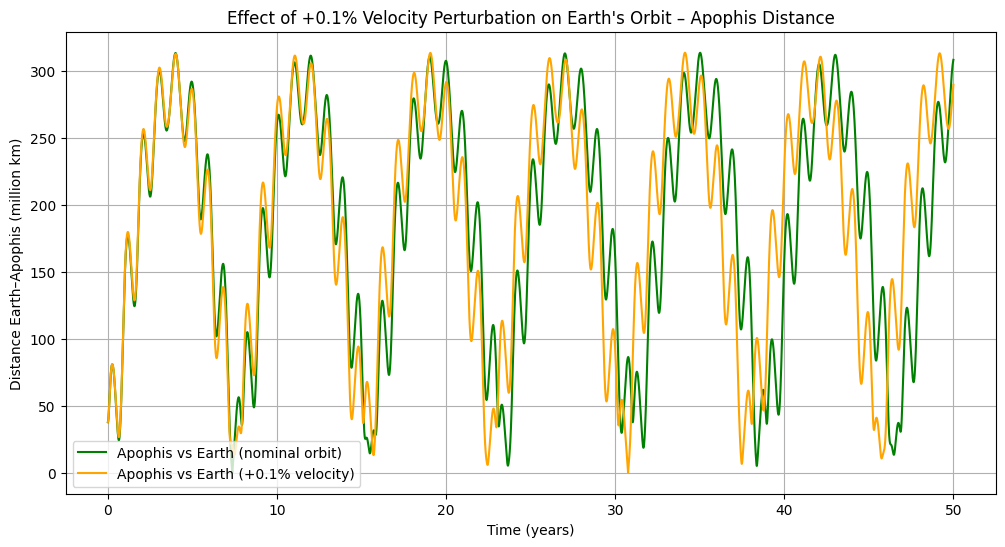

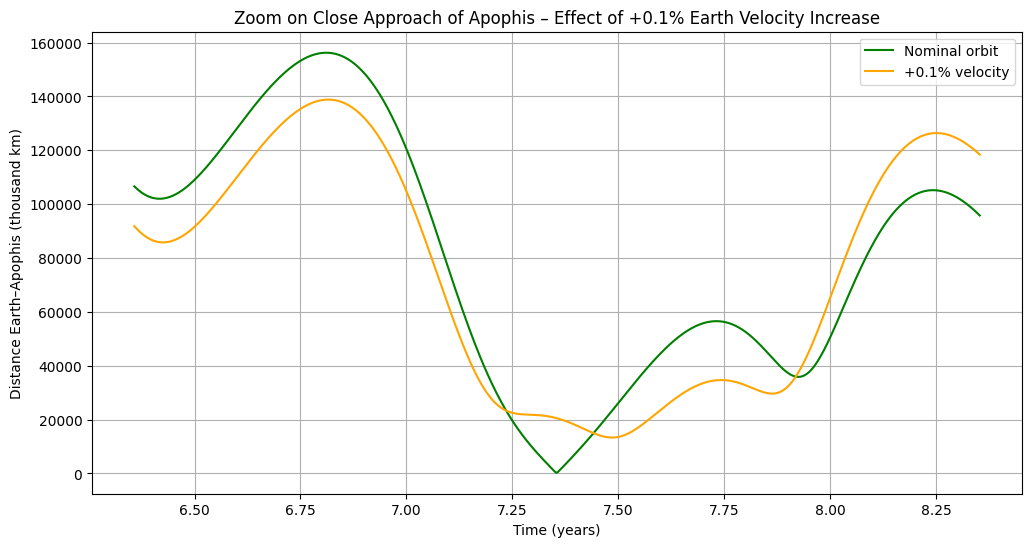

In [ ]:
#test 1
import numpy as np
import matplotlib.pyplot as plt

# Constants
AU = 149597870.7  # km
mu_sun = 1.32712440018e11  # km^3/s^2 (GM of Sun)
days_in_sec = 86400

# Earth's circular orbit parameters
r_earth = AU
v_circular = np.sqrt(mu_sun / r_earth)  # ~29.78 km/s

# Perturbed velocity (+0.1%)
v_perturbed = v_circular * 1.001

# Orbital period (nominal Earth)
T_earth = 2 * np.pi * np.sqrt(r_earth**3 / mu_sun) / days_in_sec  # in days

# Apophis (99942) orbital parameters (approx)
a_ast = 0.9224 * AU
e_ast = 0.191
P_ast = np.sqrt(a_ast**3 / AU**3) * 365.25  # days

# Time span (50 years)
days = np.linspace(0, 50*365, 20000)

# --- Earth orbits ---
# Nominal circular orbit
theta_earth = 2*np.pi*days/365.25
x_earth = r_earth * np.cos(theta_earth)
y_earth = r_earth * np.sin(theta_earth)

# Perturbed orbit: compute new ellipse from vis-viva
energy = v_perturbed**2/2 - mu_sun/r_earth
a_new = -mu_sun / (2*energy)  # semi-major axis
e_new = np.sqrt(1 - (r_earth * v_perturbed**2)/mu_sun * (r_earth/a_new))

# Mean motion
n_new = np.sqrt(mu_sun / a_new**3) * days_in_sec  # rad/day

# Mean anomaly for perturbed orbit
M_new = n_new * days

# Solve Kepler’s equation for perturbed Earth
E_new = np.zeros_like(M_new)
for i, m in enumerate(M_new):
    e_guess = m
    for _ in range(15):
        e_guess -= (e_guess - e_new*np.sin(e_guess) - m) / (1 - e_new*np.cos(e_guess))
    E_new[i] = e_guess

# True anomaly
nu_new = 2*np.arctan2(np.sqrt(1+e_new)*np.sin(E_new/2), np.sqrt(1-e_new)*np.cos(E_new/2))

# Distance from Sun
r_new = a_new * (1 - e_new*np.cos(E_new))

# Perturbed coords
x_earth_pert = r_new * np.cos(nu_new)
y_earth_pert = r_new * np.sin(nu_new)

# --- Apophis orbit ---
M_ast = 2*np.pi*days/P_ast
E_ast = np.zeros_like(M_ast)

for i, m in enumerate(M_ast):
    e_guess = m
    for _ in range(15):
        e_guess -= (e_guess - e_ast*np.sin(e_guess) - m) / (1 - e_ast*np.cos(e_guess))
    E_ast[i] = e_guess

nu_ast = 2*np.arctan2(np.sqrt(1+e_ast)*np.sin(E_ast/2), np.sqrt(1-e_ast)*np.cos(E_ast/2))
r_ast = a_ast * (1 - e_ast*np.cos(E_ast))
x_ast = r_ast * np.cos(nu_ast)
y_ast = r_ast * np.sin(nu_ast)

# Distances
dist_original = np.sqrt((x_ast - x_earth)**2 + (y_ast - y_earth)**2)
dist_perturbed = np.sqrt((x_ast - x_earth_pert)**2 + (y_ast - y_earth_pert)**2)

# Find min distances
min_idx_orig = np.argmin(dist_original)
min_idx_pert = np.argmin(dist_perturbed)

print("Apophis – minimum Earth distance (original): {:.0f} km at year {:.2f}".format(
    dist_original[min_idx_orig], days[min_idx_orig]/365))
print("Apophis – minimum Earth distance (+0.1% velocity): {:.0f} km at year {:.2f}".format(
    dist_perturbed[min_idx_pert], days[min_idx_pert]/365))

#display
plt.figure(figsize=(12,6))
  #normal vs changed
plt.plot(days/365, dist_original/1e6, label="Apophis vs Earth (nominal orbit)", color="green")
plt.plot(days/365, dist_perturbed/1e6, label="Apophis vs Earth (+0.1% velocity)", color="orange")
plt.xlabel("Time (years)")
plt.ylabel("Distance Earth–Apophis (million km)")
plt.title("Effect of +0.1% Velocity Perturbation on Earth's Orbit – Apophis Distance")
plt.legend()
plt.grid(True)
plt.show()

#display (zoom)
  #settings
window = 365
mask = (days > days[min_idx_orig]-window) & (days < days[min_idx_orig]+window)

plt.figure(figsize=(12,6))
  #normal vs changed
plt.plot(days[mask]/365, dist_original[mask]/1e3, label="Nominal orbit", color="green")
plt.plot(days[mask]/365, dist_perturbed[mask]/1e3, label="+0.1% velocity", color="orange")
plt.xlabel("Time (years)")
plt.ylabel("Distance Earth–Apophis (thousand km)")
plt.title("Zoom on Close Approach of Apophis – Effect of +0.1% Earth Velocity Increase")
plt.legend()
plt.grid(True)
plt.show()


The +0.1% velocity makes the NEO reach a certain distance away from Earth faster than the normal orbit. This speed gradually increases. In addition, I chose the years of 50 as that was our first window. Then, I chose to zoom at 8.5 because that was where the first change roughly happened.

Analyze green then to see how it changes in comparison with yellow

NEO 1: Highest rate of being hazardous

2024 YR4

figures in a slideshow --> to show the

2024 YR4 – minimum Earth distance (original): 2704456 km at year 4.15
2024 YR4 – minimum Earth distance (+0.1% velocity): 7406400 km at year 4.14


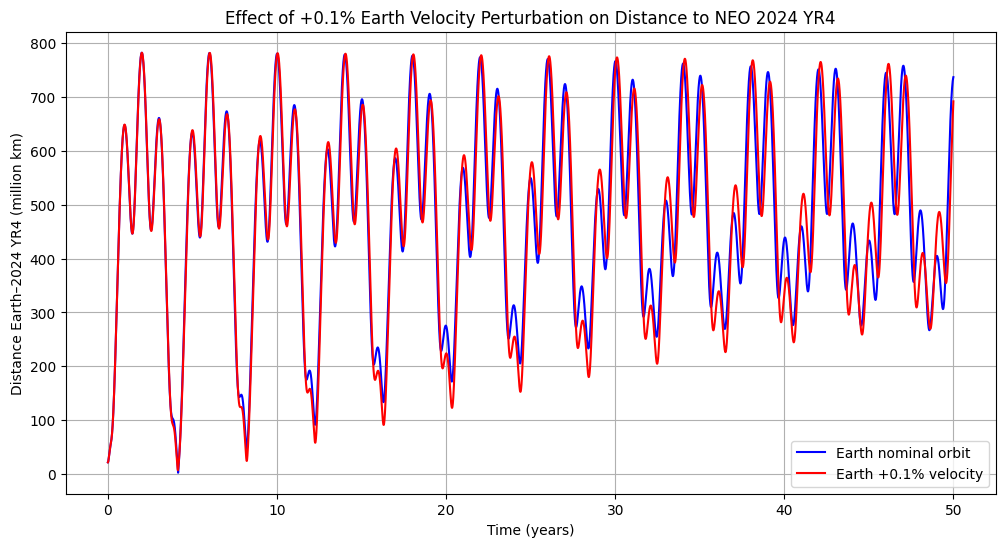

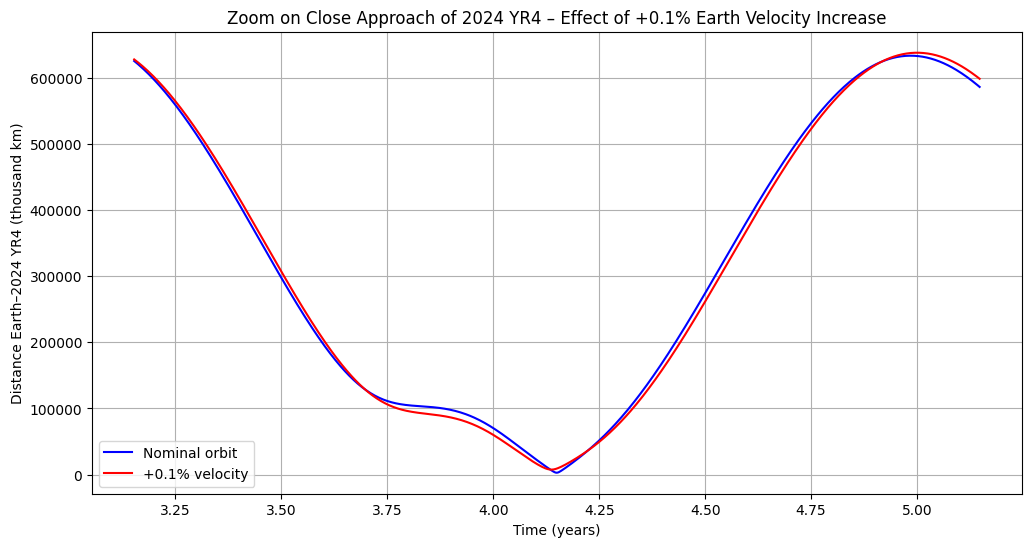

In [ ]:
#test 2
import numpy as np
import matplotlib.pyplot as plt

# Constants
AU = 149597870.7  # km
mu_sun = 1.32712440018e11  # km^3/s^2 (GM of Sun)
days_in_sec = 86400

# === Earth orbit ===
r_earth = AU
v_circular = np.sqrt(mu_sun / r_earth)  # ~29.78 km/s
v_perturbed = v_circular * 1.001  # +0.1% velocity increase
T_earth = 2 * np.pi * np.sqrt(r_earth**3 / mu_sun) / days_in_sec  # in days

# === 2024 YR4 orbital parameters (approx) ===
a_ast = 2.5400 * AU
e_ast = 0.664269
P_ast = np.sqrt(a_ast**3 / AU**3) * 365.25  # orbital period in days (~1478.6)

# Time span: 50 years
days = np.linspace(0, 50*365, 20000)

# === Earth positions ===
theta_earth = 2 * np.pi * days / 365.25
x_earth = r_earth * np.cos(theta_earth)
y_earth = r_earth * np.sin(theta_earth)

# --- Perturbed Earth orbit ---
energy = v_perturbed**2/2 - mu_sun/r_earth
a_new = -mu_sun / (2*energy)
e_new = np.sqrt(1 - (r_earth * v_perturbed**2)/mu_sun * (r_earth/a_new))
n_new = np.sqrt(mu_sun / a_new**3) * days_in_sec  # rad/day

M_new = n_new * days
E_new = np.zeros_like(M_new)

for i, m in enumerate(M_new):
    e_guess = m
    for _ in range(15):
        e_guess -= (e_guess - e_new*np.sin(e_guess) - m) / (1 - e_new*np.cos(e_guess))
    E_new[i] = e_guess

nu_new = 2 * np.arctan2(np.sqrt(1+e_new)*np.sin(E_new/2),
                        np.sqrt(1-e_new)*np.cos(E_new/2))
r_new = a_new * (1 - e_new*np.cos(E_new))
x_earth_pert = r_new * np.cos(nu_new)
y_earth_pert = r_new * np.sin(nu_new)

# === 2024 YR4 orbit ===
M_ast = 2*np.pi*days/P_ast
E_ast = np.zeros_like(M_ast)

for i, m in enumerate(M_ast):
    e_guess = m
    for _ in range(15):
        e_guess -= (e_guess - e_ast*np.sin(e_guess) - m) / (1 - e_ast*np.cos(e_guess))
    E_ast[i] = e_guess

nu_ast = 2*np.arctan2(np.sqrt(1+e_ast)*np.sin(E_ast/2),
                      np.sqrt(1-e_ast)*np.cos(E_ast/2))
r_ast = a_ast * (1 - e_ast*np.cos(E_ast))
x_ast = r_ast * np.cos(nu_ast)
y_ast = r_ast * np.sin(nu_ast)

# === Distances Earth ↔ 2024 YR4 ===
dist_original = np.sqrt((x_ast - x_earth)**2 + (y_ast - y_earth)**2)
dist_perturbed = np.sqrt((x_ast - x_earth_pert)**2 + (y_ast - y_earth_pert)**2)

# === Find minimum distances ===
min_idx_orig = np.argmin(dist_original)
min_idx_pert = np.argmin(dist_perturbed)

print("2024 YR4 – minimum Earth distance (original): {:.0f} km at year {:.2f}".format(
    dist_original[min_idx_orig], days[min_idx_orig]/365))
print("2024 YR4 – minimum Earth distance (+0.1% velocity): {:.0f} km at year {:.2f}".format(
    dist_perturbed[min_idx_pert], days[min_idx_pert]/365))

# === Plot (full 50 years) ===
plt.figure(figsize=(12,6))
plt.plot(days/365, dist_original/1e6, label="Earth nominal orbit", color="blue")
plt.plot(days/365, dist_perturbed/1e6, label="Earth +0.1% velocity", color="red")
plt.xlabel("Time (years)")
plt.ylabel("Distance Earth–2024 YR4 (million km)")
plt.title("Effect of +0.1% Earth Velocity Perturbation on Distance to NEO 2024 YR4")
plt.legend()
plt.grid(True)
plt.show()

# === Zoom near closest approach ===
window = 365
mask = (days > days[min_idx_orig]-window) & (days < days[min_idx_orig]+window)

plt.figure(figsize=(12,6))
plt.plot(days[mask]/365, dist_original[mask]/1e3, label="Nominal orbit", color="blue")
plt.plot(days[mask]/365, dist_perturbed[mask]/1e3, label="+0.1% velocity", color="red")
plt.xlabel("Time (years)")
plt.ylabel("Distance Earth–2024 YR4 (thousand km)")
plt.title("Zoom on Close Approach of 2024 YR4 – Effect of +0.1% Earth Velocity Increase")
plt.legend()
plt.grid(True)
plt.show()


Flip the graph --> showing that it gets closer

Although it is supposed to be the more hazardous one, it does not collide with Earth similar to the other one.

Compare to the ones made by NASA (ex. 4 years, +- 4)

|

## REDO
With more parameters and constants

Must haves (basics):
- Epoch (t_0): the exact time your initial state is defined
    1. Heliocentric Cartesian
          
                position: x_0
                velocity: v_0
    2. Osculating Keplerian elements
          
                eccentricity: e
                semi-major axis: a (AU)
                inclination: i (degrees)
                longitude of accending node: Ω
                perihelion: 𝜔 (AU)
                mean anomaly: M_0

                rest can be derived from set parameters
- Fixed environment/constants
    1. Gravitational parameters
    
                𝜇⊙ = GM⊙ = 1.32712440018 × 10²⁰ m³/s² (sun's graviational parameter)
                𝜇⊕ = GM⊕ = 3.986004418 × 10¹⁴ m³/s² (Earth's graviational parameter)


Code parameter matching:

- Fixed parameters (variable names)
    
        ecc: eccentricity
        sm_axis: semi-major axis (AU)
        inc: inclination (degrees)
        asc_node: longitude of accending node (Ω)
        p_helion: perihelion (𝜔)&&(AU)
        mean: mean anomaly


Changes and overall notes since the expert (Adam Almakroudi) meeting

- *We are changing the NEO's velocity—instead of Earth—as it has a larger chance of fluctuation*

- Kelper's Laws

        1). The law of orbits states that planets move in elliptical paths with the sun at one focus
        2). The law of areas says a line connecting a planet to the sun sweeps out equal areas in equal times, meaning planets move faster when closer to the sun and slower when farther away.
        3). The law of periods establishes that the square of a planet's orbital period is proportional to the cube of its semi-major axis (average distance from the sun).

- Velocity change as it will change the NEO's eccentricity and semi-major axis
- Changes to Kepler's calculations

        Previously Newton Ruphson Method changing to ____.
              Newton Ruphson Method can be fail or oscillate for high eccentricities (e → 1). In addition, it converges quadratically only if the initial guess is near the true root. Lastly, it can get stuck for hyperbolic orbits (e > 1) unless modified.

              
-

Check to see if Newton-Raphson is strong enough

    Calcuations

Changes and overall notes since the expert (Adam Almakroudi) meeting

- *We are changing the NEO's velocity—instead of Earth—as it has a larger chance of fluctuation*

- Kelper's Laws

        1). The law of orbits states that planets move in elliptical paths with the sun at one focus
        2). The law of areas says a line connecting a planet to the sun sweeps out equal areas in equal times, meaning planets move faster when closer to the sun and slower when farther away.
        3). The law of periods establishes that the square of a planet's orbital period is proportional to the cube of its semi-major axis (average distance from the sun).

- Velocity change as it will change the NEO's eccentricity and semi-major axis
- Changes to Kepler's calculations

        Previously Newton Ruphson Method changing to ____.
              Newton Ruphson Method can be fail or oscillate for high eccentricities (e → 1). In addition, it converges quadratically only if the initial guess is near the true root. Lastly, it can get stuck for hyperbolic orbits (e > 1) unless modified.

              
-

**Simulation 1: Currently Hazardous**

    NEO: 2024 YR4

Parameters: (source - NASA & SBDB)
- Eccentricity --> **ecc** (e): 0.66426900
- Semi-major axis --> **sm_axis** (a): 2.54000858 AU
- Inclination --> **inc** (i): 3.45326192°
- Longitude of ascending node --> **asc_node** (Ω): 271.41230059°
- Perihelion --> **p_helion** (ω): 134.64151115°
- Mean anomaly --> **mean** (M₀): 351.07992528°

Perturbation:
- +0.1% velocity (to NEO)

Notes:
-  high eccentricity x > 0.5


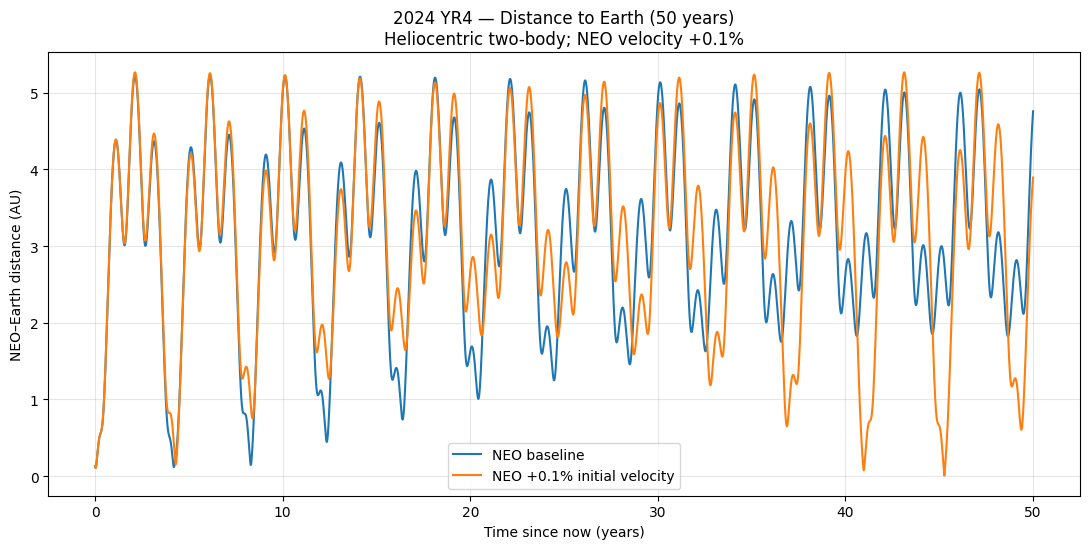

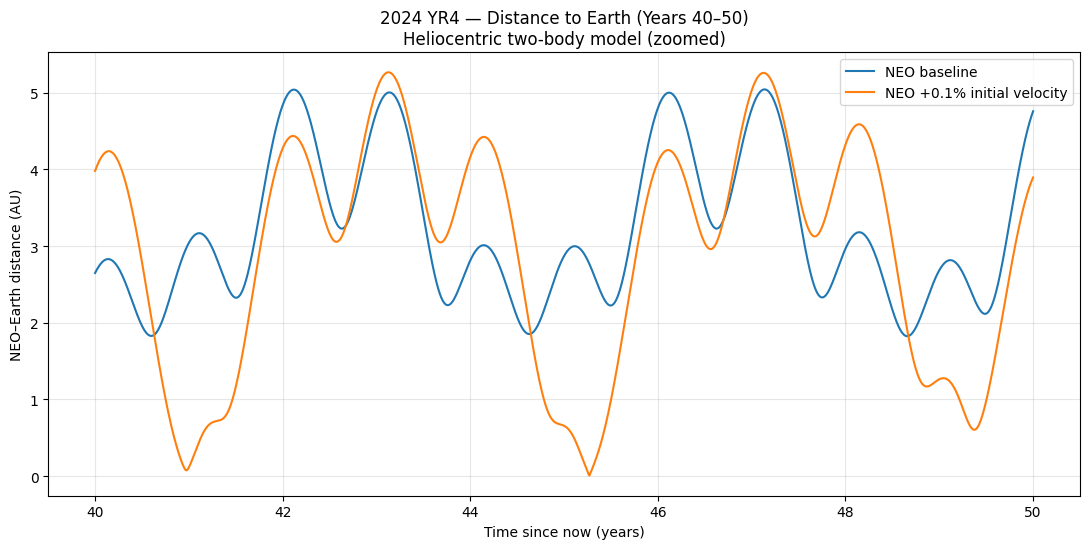

Diagnostics
Min distance (baseline NEO):  0.106 AU
Min distance (perturbed NEO): 0.006 AU
Max |Δdistance| over 50y:     2.930 AU


In [ ]:
#2024 YR4 with +0.1% on NEO's velocity + Newton Raphson Method
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# PHYSICAL CONSTANTS (labeled)======================================================
  #Units
AU   = 1.495978707e11        # [m] Astronomical Unit
DAY  = 86400.0               # [s]
YEAR = 365.25 * DAY          # [s]

  #Sun
mu_sun   = 1.32712440018e20  # [m^3/s^2] GM☉

  #Earth (for distance reference; Earth dynamics are 2-body around Sun)
mu_earth = 3.986004418e14    # [m^3/s^2] GM⊕  (not used in this simple heliocentric model)
r_earth_mean = AU            # [m] 1 AU circular orbit
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  # [m/s]

# ORBITAL ELEMENTS: NEO 2024 YR4  (use user's variable names)======================================================
ecc      = 0.66426900         # eccentricity (e)
sm_axis  = 2.54000858         # semi-major axis (a) in AU
inc      = 3.45326192         # inclination (i) in degrees
asc_node = 271.41230059       # longitude of ascending node (Ω) in degrees
p_helion = 134.64151115       # argument of perihelion (ω) in degrees
mean     = 351.07992528       # mean anomaly (M₀) in degrees

  #Convert to radians / SI
a     = sm_axis * AU
i     = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0    = np.deg2rad(mean)

# KEPLER + ORBITAL CONVERSIONS======================================================
  #Newton-Raphson Method
def solve_kepler(M, e, tol=1e-12, maxiter=100):
    """Solve Kepler’s equation M = E - e*sin(E) for E (elliptic)."""
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E

def oe_to_state(a, e, i, Omega, omega, M, mu):
    """Classical elements → Cartesian state (heliocentric, inertial)."""
    E = solve_kepler(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #Perifocal (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h   = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #Rotation PQW→IJK
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p,  y_p,  0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

def two_body_rhs(t, y, mu):
    """Two-body ODE (Sun-centered)."""
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

# INITIAL CONDITIONS (t = now)======================================================
  #NEO baseline
r_neo0, v_neo0 = oe_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
  #NEO perturbed: +0.1% to velocity magnitude (same direction)
v_neo0_pert = v_neo0 * 1.001

  #Earth baseline (1 AU circular)
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

# TIME GRID======================================================
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

# PROPAGATION (Sun-centered two-body)======================================================
  #NEO baseline
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)),
                    args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #NEO perturbed
sol_neo_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0_pert)),
                      args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)
  #Earth
sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)),
                      args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

  #Positions
rN  = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE  = sol_earth.y[:3].T

#DISTANCES (NEO–Earth)======================================================
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

# PLOT 1 — Full 50-year overlay======================================================
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="NEO baseline")
plt.plot(time_years, dist_pert_AU, label="NEO +0.1% initial velocity")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2024 YR4 — Distance to Earth (50 years)\nHeliocentric two-body; NEO velocity +0.1%")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#PLOT 2 — Zoom at y=0======================================================
mask = (time_years >= 40) & (time_years <= 50)
plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="NEO baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], label="NEO +0.1% initial velocity")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2024 YR4 — Distance to Earth (Years 40–50)\nHeliocentric two-body model (zoomed)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#DIAGNOSTICS======================================================
print("Diagnostics")
print(f"Min distance (baseline NEO):  {dist_base_AU.min():.3f} AU")
print(f"Min distance (perturbed NEO): {dist_pert_AU.min():.3f} AU")
print(f"Max |Δdistance| over 50y:     {np.max(diff_AU):.3f} AU")

Calculation to see if Newton Raphson Method is strong enough



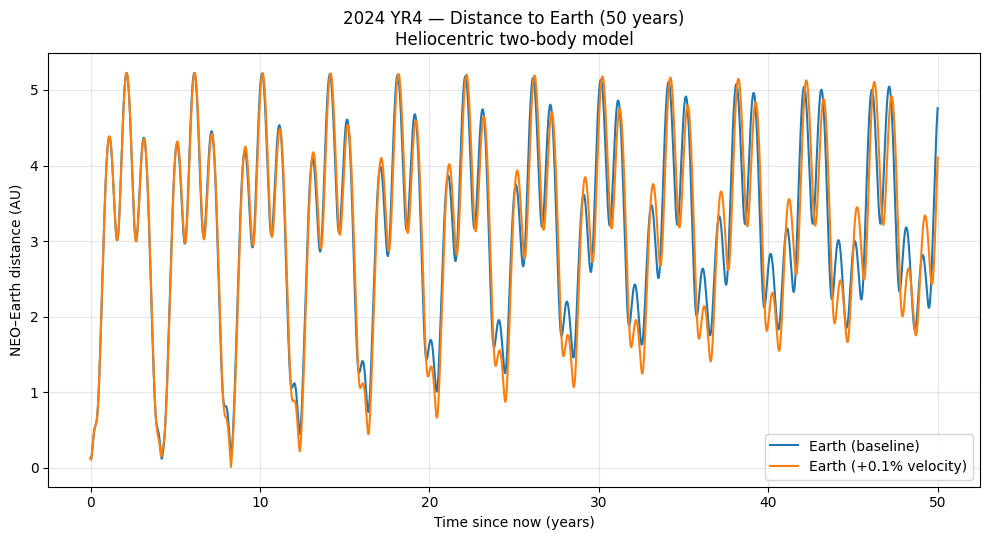

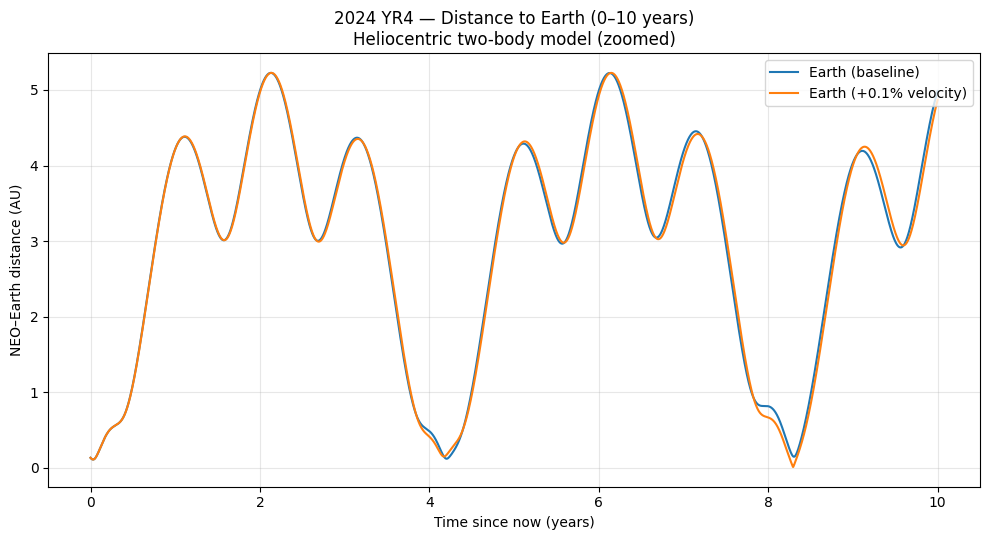

Diagnostics
Min distance (baseline):  0.106 AU
Min distance (perturbed): 0.007 AU
Max |Δdistance|:           0.909 AU


In [ ]:
#2024 YR4 with +0.1% on Earth's velocity (first one --> old one --> improved one above) --> with all the changes described in the redo section
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#PHYSICAL CONSTANTS ======================================================
  #Universals and Units
AU = 1.495978707e11      #[m] --> Astronomical Unit
DAY = 86400.0            #[s] --> Seconds per day
YEAR = 365.25 * DAY      #[s] --> Seconds per Julian year

  #Sun
mu_sun = 1.32712440018e20    #[m^3/s^2] --> Sun’s standard gravitational parameter (GM☉)

  #Earth
mu_earth = 3.986004418e14    #[m^3/s^2] --> Earth’s standard gravitational parameter (GM⊕)
r_earth_mean = AU            #[m] --> Mean orbital radius of Earth (1 AU)
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  #[m/s] --> Mean orbital velocity of Earth



#ORBITAL ELEMENTS: NEO 2024 YR4 ======================================================
ecc = 0.66426900                   #eccentricity
sm_axis = 2.54000858               #semi-major axis (AU)
inc = 3.45326192                   #inclination (degrees)
asc_node = 271.41230059            #longitude of ascending node (degrees)
p_helion = 134.64151115            #perihelion (degrees)
mean = 351.07992528                #mean anomaly (degrees)

# Convert to radians/SI
a = sm_axis * AU
i = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0 = np.deg2rad(mean)

#KEPLER + ORBITAL CONVERSIONS ======================================================
  #Newton Raphson Method
def solve_kepler(M, e, tol=1e-12, maxiter=100):
    """Solve Kepler’s equation M = E - e*sin(E) for E."""
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E

def oe_to_state(a, e, i, Omega, omega, M, mu):
    """Convert orbital elements → Cartesian position & velocity."""
    E = solve_kepler(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    #perifocal frame (PQW)
    x_p, y_p = r * np.cos(nu), r * np.sin(nu)
    h = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    #rotation PQW → inertial frame
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)
    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])
    r_vec = R @ np.array([x_p, y_p, 0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

def two_body_rhs(t, y, mu):
    """Two-body equations of motion under central gravity."""
    r, v = y[:3], y[3:]
    a_vec = -mu * r / np.linalg.norm(r)**3
    return np.hstack((v, a_vec))

#INITIAL CONDITIONS (t = now)======================================================
r_neo0, v_neo0 = oe_to_state(a, ecc, i, Omega, omega, M0, mu_sun)

  #Earth (heliocentric, circular, 1 AU)
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])
v_earth0_pert = v_earth0 * 1.001   #+0.1% perturbation to Earth's velocity

#TIME GRID======================================================
t0 = 0.0
tf = 50 * YEAR
n_days = int(tf / DAY)
t_eval = np.linspace(t0, tf, n_days + 1)
time_years = t_eval / YEAR

#PROPAGATE ORBITS (Sun-centered)======================================================
sol_neo = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_neo0, v_neo0)),
                    args=(mu_sun,), t_eval=t_eval, rtol=1e-9, atol=1e-9)

sol_earth = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0)),
                      args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

sol_earth_p = solve_ivp(two_body_rhs, (t0, tf), np.hstack((r_earth0, v_earth0_pert)),
                        args=(mu_sun,), t_eval=t_eval, rtol=1e-10, atol=1e-10)

#DISTANCE CALCULATIONS======================================================
rN = sol_neo.y[:3].T
rE = sol_earth.y[:3].T
rEp = sol_earth_p.y[:3].T

dist_base_AU = np.linalg.norm(rN - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rN - rEp, axis=1) / AU

#PLOT 1 — Full 50-year view======================================================
plt.figure(figsize=(10, 5.5))
plt.plot(time_years, dist_base_AU, label="Earth (baseline)")
plt.plot(time_years, dist_pert_AU, label="Earth (+0.1% velocity)")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2024 YR4 — Distance to Earth (50 years)\nHeliocentric two-body model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#PLOT 2 — Zoom between 0 and 10 years======================================================
mask = (time_years >= 0) & (time_years <= 10)
plt.figure(figsize=(10, 5.5))
plt.plot(time_years[mask], dist_base_AU[mask], label="Earth (baseline)")
plt.plot(time_years[mask], dist_pert_AU[mask], label="Earth (+0.1% velocity)")
plt.xlabel("Time since now (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2024 YR4 — Distance to Earth (0–10 years)\nHeliocentric two-body model (zoomed)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#DIAGNOSTICS======================================================
print("Diagnostics")
print(f"Min distance (baseline):  {dist_base_AU.min():.3f} AU")
print(f"Min distance (perturbed): {dist_pert_AU.min():.3f} AU")
print(f"Max |Δdistance|:           {np.max(np.abs(dist_base_AU - dist_pert_AU)):.3f} AU")


**Simulation 2: Could Become Hazardous**

    NEO: 2000 SG344

Parameters: (source -  JPL Horizons & SBDB)
- Eccentricity --> **ecc** (e): 0.06696
- Semi-major axis --> **sm_axis** (a): 0.97744 AU
- Inclination --> **inc** (i): 0.112°
- Longitude of ascending node --> **asc_node** (Ω): 191.91°
- Perihelion --> **p_helion** (ω): 275.35°
- Mean anomaly --> **mean** (M₀): 35.68°

Perturbation:
- +0.1% velocity

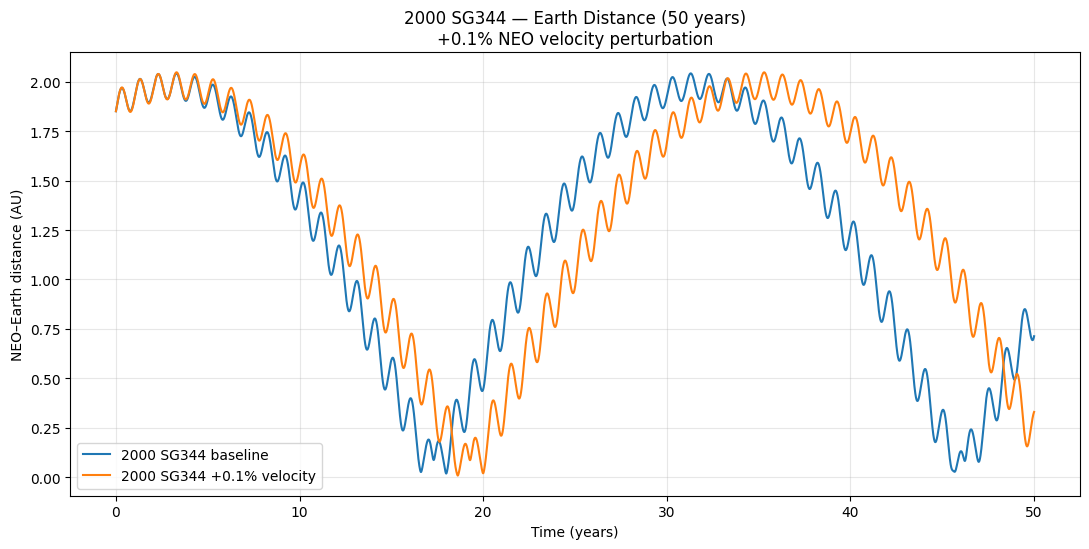

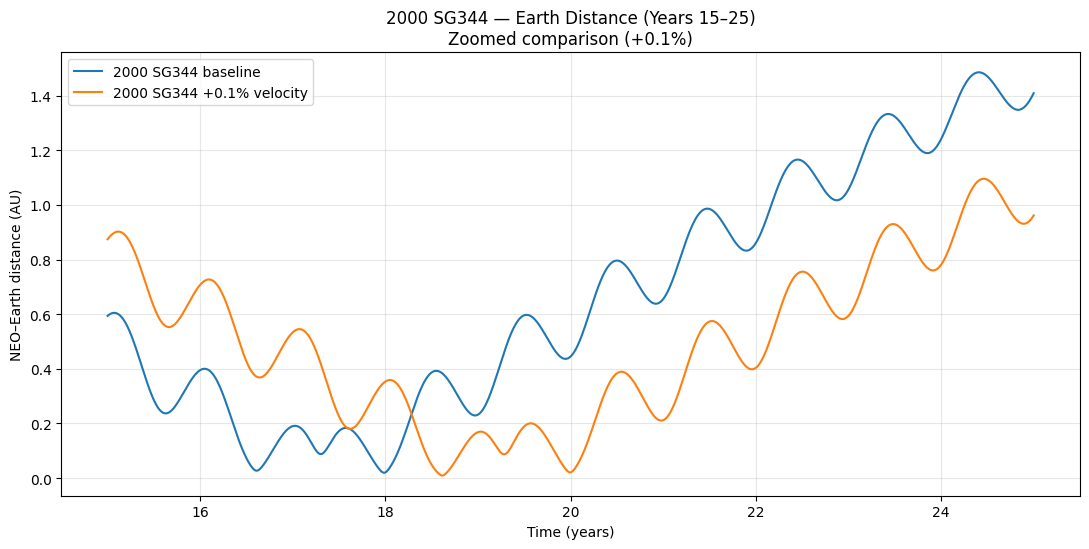

Diagnostics:
  Min distance baseline:  0.020 AU
  Min distance perturbed: 0.009 AU
  Max Δdistance:          0.981 AU


In [ ]:
# 2000 SG344 — NEO–Earth distance with +0.2% NEO velocity perturbation
# Requirements: numpy, scipy, matplotlib

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ======================================================
# PHYSICAL CONSTANTS (labeled)
# ======================================================
AU   = 1.495978707e11        # [m] Astronomical Unit
DAY  = 86400.0               # [s]
YEAR = 365.25 * DAY          # [s]

# Sun
mu_sun   = 1.32712440018e20  # [m^3/s^2] GM☉

# Earth (reference orbit)
mu_earth = 3.986004418e14
r_earth_mean = AU
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)

# ======================================================
# ORBITAL ELEMENTS: 2000 SG344 (user variable names)
# ======================================================
ecc      = 0.06696
sm_axis  = 0.97744     # AU
inc      = 0.112
asc_node = 191.91
p_helion = 275.35
mean     = 35.68

# Convert to radians / SI units
a     = sm_axis * AU
i     = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0    = np.deg2rad(mean)

# ======================================================
# KEPLER + STATE CONVERSION
# ======================================================
def solve_kepler(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E

def oe_to_state(a, e, i, Omega, omega, M, mu):
    E = solve_kepler(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1-e**2)*sinE, cosE - e)

    x_p = r * np.cos(nu)
    y_p = r * np.sin(nu)
    h   = np.sqrt(mu*a*(1-e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    # Rotation matrix PQW → inertial (IJK)
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)

    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])

    r_vec = R @ np.array([x_p, y_p, 0])
    v_vec = R @ np.array([vx_p, vy_p, 0])
    return r_vec, v_vec

def two_body_rhs(t, y, mu):
    r = y[:3]
    v = y[3:]
    a = -mu * r / np.linalg.norm(r)**3
    return np.concatenate((v, a))


# ======================================================
# INITIAL CONDITIONS
# ======================================================
r_neo0, v_neo0 = oe_to_state(a, ecc, i, Omega, omega, M0, mu_sun)

# *** +0.1% velocity perturbation ***
v_neo0_pert = v_neo0 * 1.001

# Earth (1 AU circular orbit)
r_earth0 = np.array([r_earth_mean, 0, 0])
v_earth0 = np.array([0, v_earth_mean, 0])

# ======================================================
# TIME SPAN
# ======================================================
t0 = 0
tf = 50 * YEAR
t_eval = np.linspace(t0, tf, int(tf / DAY) + 1)
time_years = t_eval / YEAR

# ======================================================
# PROPAGATE ORBITS
# ======================================================
sol_neo = solve_ivp(
    two_body_rhs, (t0, tf), np.concatenate((r_neo0, v_neo0)),
    t_eval=t_eval, args=(mu_sun,), rtol=1e-9, atol=1e-9
)

sol_neo_p = solve_ivp(
    two_body_rhs, (t0, tf), np.concatenate((r_neo0, v_neo0_pert)),
    t_eval=t_eval, args=(mu_sun,), rtol=1e-9, atol=1e-9
)

sol_earth = solve_ivp(
    two_body_rhs, (t0, tf), np.concatenate((r_earth0, v_earth0)),
    t_eval=t_eval, args=(mu_sun,), rtol=1e-10, atol=1e-10
)

rN  = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE  = sol_earth.y[:3].T

# ======================================================
# DISTANCES
# ======================================================
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

# ======================================================
# PLOT 1 — 50-year comparison
# ======================================================
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="2000 SG344 baseline")
plt.plot(time_years, dist_pert_AU, label="2000 SG344 +0.1% velocity")
plt.xlabel("Time (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2000 SG344 — Earth Distance (50 years)\n+0.1% NEO velocity perturbation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# PLOT 2 — Zoom 15–25 years
# ======================================================
mask = (time_years >= 15) & (time_years <= 25)

plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="2000 SG344 baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], label="2000 SG344 +0.1% velocity")
plt.xlabel("Time (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2000 SG344 — Earth Distance (Years 15–25)\nZoomed comparison (+0.1%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# DIAGNOSTICS
# ======================================================
print("Diagnostics:")
print(f"  Min distance baseline:  {dist_base_AU.min():.3f} AU")
print(f"  Min distance perturbed: {dist_pert_AU.min():.3f} AU")
print(f"  Max Δdistance:          {np.max(np.abs(dist_base_AU - dist_pert_AU)):.3f} AU")


**Simulation 3: Could Become Hazardous**

    NEO: 2025 FA22

Parameters: (source - JPL SBDB solution JPL#24)
- Eccentricity --> **ecc** (e): 0.4149151053
- Semi-major axis --> **sm_axis** (a): 1.5072249272 AU
- Inclination --> **inc** (i): 7.5470805628°
- Longitude of ascending node --> **asc_node** (Ω): 356.5060673229°
- Perihelion --> **p_helion** (ω): 304.9130604139°
- Mean anomaly --> **mean** (M₀): 309.6876512°

Perturbation:
- +0.1% velocity


**Still newton-raphson method**

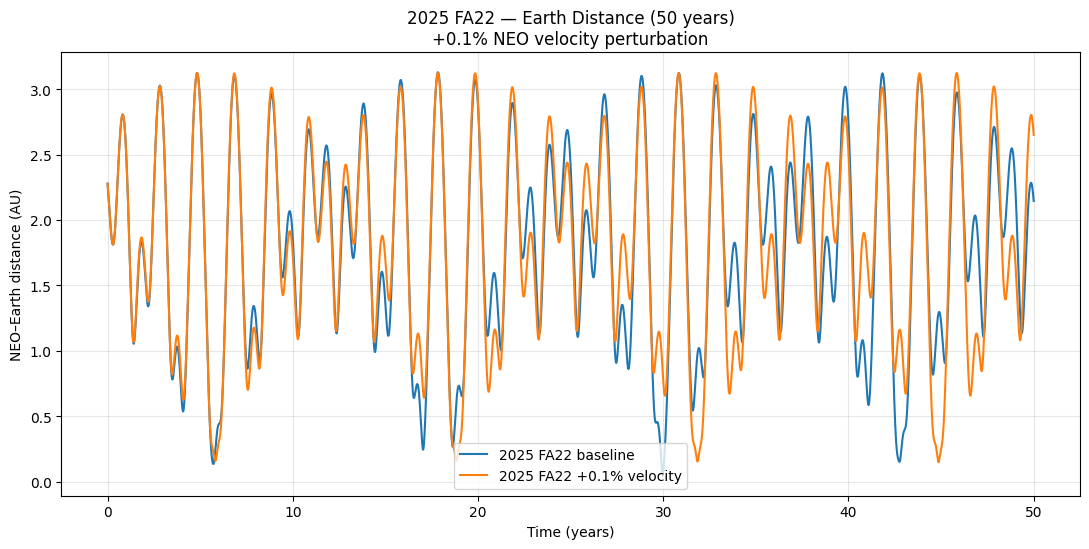

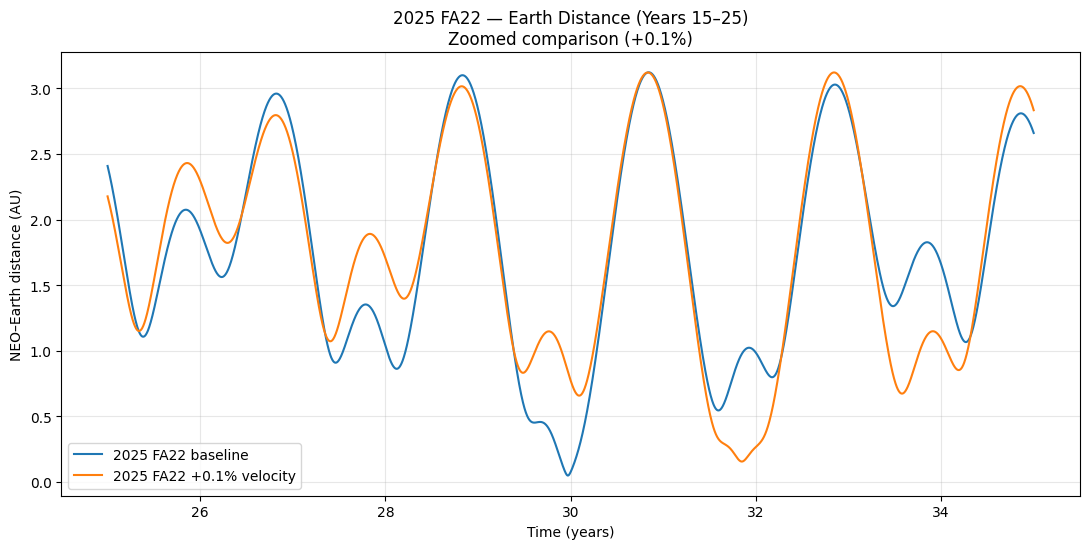

Diagnostics:
  Min distance baseline:  0.047 AU
  Min distance perturbed: 0.149 AU
  Max Δdistance:          1.142 AU


In [ ]:
# 2025 FA22 — NEO–Earth distance with +0.2% NEO velocity perturbation
# Requirements: numpy, scipy, matplotlib

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ======================================================
# PHYSICAL CONSTANTS (labeled)
# ======================================================
# Units
AU   = 1.495978707e11        # [m] Astronomical Unit
DAY  = 86400.0               # [s]
YEAR = 365.25 * DAY          # [s]

# Sun
mu_sun   = 1.32712440018e20  # [m^3/s^2] GM☉

# Earth (reference orbit only; not used dynamically beyond Sun–Earth 2-body)
mu_earth = 3.986004418e14    # [m^3/s^2] GM⊕
r_earth_mean = AU            # [m]
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)  # [m/s]

# ======================================================
# ORBITAL ELEMENTS: NEO 2025 FA22 (user variable names)
# ======================================================
ecc      = 0.4149151053          # eccentricity (e)
sm_axis  = 1.5072249272          # semi-major axis (a) in AU
inc      = 7.5470805628          # inclination (i) in degrees
asc_node = 356.5060673229        # longitude of ascending node Ω (deg)
p_helion = 304.9130604139        # argument of perihelion ω (deg)
mean     = 309.6876512           # mean anomaly M₀ (deg)

# Convert to radians / SI
a     = sm_axis * AU
i     = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0    = np.deg2rad(mean)

# ======================================================
# KEPLER + ORBITAL CONVERSIONS
# ======================================================
def solve_kepler(M, e, tol=1e-12, maxiter=100):
    """Solve Kepler’s equation M = E - e*sin(E) for E (elliptic)."""
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol:
            break
    return E

def oe_to_state(a, e, i, Omega, omega, M, mu):
    """Classical orbital elements → Cartesian state (heliocentric, inertial)."""
    E = solve_kepler(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1 - e**2) * sinE, cosE - e)

    # Perifocal coordinates (PQW)
    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h   = np.sqrt(mu * a * (1 - e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    # Rotation PQW → IJK (heliocentric inertial)
    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)

    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])

    r_vec = R @ np.array([x_p, y_p, 0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec

def two_body_rhs(t, y, mu):
    """Two-body equations of motion (Sun-centered)."""
    r = y[:3]
    v = y[3:]
    a = -mu * r / np.linalg.norm(r)**3
    return np.concatenate((v, a))

# ======================================================
# INITIAL CONDITIONS (t = 0)
# ======================================================
# 2025 FA22 baseline
r_neo0, v_neo0 = oe_to_state(a, ecc, i, Omega, omega, M0, mu_sun)

# *** +0.1% velocity perturbation on FA22 ***
v_neo0_pert = v_neo0 * 1.001

# Earth on 1 AU circular orbit
r_earth0 = np.array([r_earth_mean, 0.0, 0.0])
v_earth0 = np.array([0.0, v_earth_mean, 0.0])

# ======================================================
# TIME SPAN
# ======================================================
t0 = 0.0
tf = 50 * YEAR
t_eval = np.linspace(t0, tf, int(tf / DAY) + 1)
time_years = t_eval / YEAR

# ======================================================
# PROPAGATION (Sun-centered 2-body)
# ======================================================
sol_neo = solve_ivp(
    two_body_rhs, (t0, tf),
    np.concatenate((r_neo0, v_neo0)),
    t_eval=t_eval, args=(mu_sun,),
    rtol=1e-9, atol=1e-9
)

sol_neo_p = solve_ivp(
    two_body_rhs, (t0, tf),
    np.concatenate((r_neo0, v_neo0_pert)),
    t_eval=t_eval, args=(mu_sun,),
    rtol=1e-9, atol=1e-9
)

sol_earth = solve_ivp(
    two_body_rhs, (t0, tf),
    np.concatenate((r_earth0, v_earth0)),
    t_eval=t_eval, args=(mu_sun,),
    rtol=1e-10, atol=1e-10
)

# Extract positions
rN  = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE  = sol_earth.y[:3].T

# ======================================================
# DISTANCES (FA22–Earth) in AU
# ======================================================
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU

# ======================================================
# PLOT 1 — Full 50-year comparison
# ======================================================
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="2025 FA22 baseline")
plt.plot(time_years, dist_pert_AU, label="2025 FA22 +0.1% velocity")
plt.xlabel("Time (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2025 FA22 — Earth Distance (50 years)\n+0.1% NEO velocity perturbation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# PLOT 2 — Zoom 25–35 years
# ======================================================
mask = (time_years >= 25) & (time_years <= 35)

plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="2025 FA22 baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], label="2025 FA22 +0.1% velocity")
plt.xlabel("Time (years)")
plt.ylabel("NEO–Earth distance (AU)")
plt.title("2025 FA22 — Earth Distance (Years 15–25)\nZoomed comparison (+0.1%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# DIAGNOSTICS
# ======================================================
print("Diagnostics:")
print(f"  Min distance baseline:  {dist_base_AU.min():.3f} AU")
print(f"  Min distance perturbed: {dist_pert_AU.min():.3f} AU")
print(f"  Max Δdistance:          {np.max(np.abs(dist_base_AU - dist_pert_AU)):.3f} AU")


**Simulation 4: Could Become Hazardous**

    NEO: 101955 Bennu

Parameters: (source - NASA/JPL (SBDB/Horizons))
- Eccentricity --> **ecc** (e): 0.2038
- Semi-major axis --> **sm_axis** (a): 1.1264 AU
- Inclination --> **inc** (i): 6.0349°
- Longitude of ascending node --> **asc_node** (Ω): 2.0609°
- Perihelion --> **p_helion** (ω): 66.2231°
- Mean anomaly --> **mean** (M₀): 101.7039°

Perturbation:
- +0.1% velocity

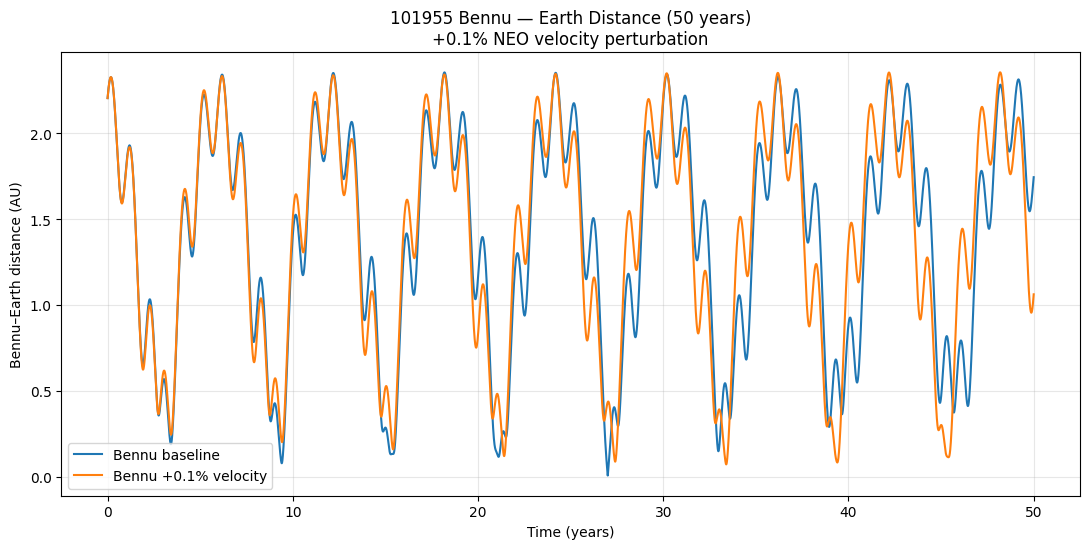

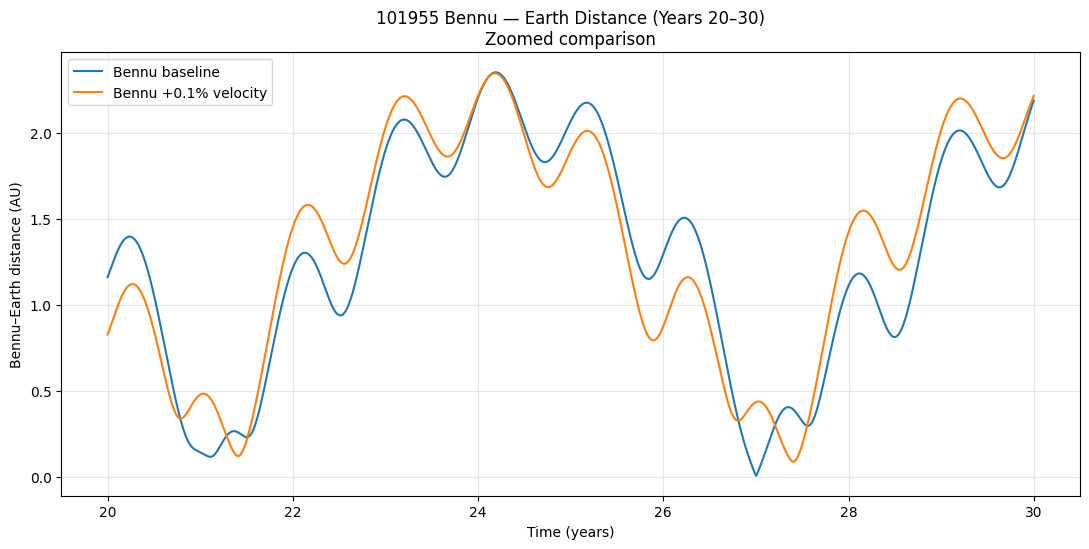

Diagnostics:
  Min distance baseline:  0.007 AU
  Min distance perturbed: 0.072 AU
  Max Δdistance:          0.790 AU


In [ ]:
# 101955 Bennu — NEO–Earth distance with +0.1% NEO velocity perturbation
# Requirements: numpy, scipy, matplotlib

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ======================================================
# PHYSICAL CONSTANTS (labeled)
# ======================================================
# Units
AU   = 1.495978707e11        # [m] Astronomical Unit
DAY  = 86400.0               # [s]
YEAR = 365.25 * DAY          # [s]

# Sun
mu_sun   = 1.32712440018e20  # [m^3/s^2] GM☉

# Earth (for distance reference only)
mu_earth = 3.986004418e14    # [m^3/s^2] GM⊕ (not used for heliocentric 2-body)
r_earth_mean = AU            # [m]
v_earth_mean = np.sqrt(mu_sun / r_earth_mean)


# ======================================================
# ORBITAL ELEMENTS: 101955 Bennu (user variable names)
# ======================================================
ecc      = 0.2038      # eccentricity
sm_axis  = 1.1264      # semi-major axis (AU)
inc      = 6.0349      # inclination (deg)
asc_node = 2.0609      # longitude of ascending node Ω (deg)
p_helion = 66.2231     # argument of perihelion ω (deg)
mean     = 101.7039    # mean anomaly M₀ (deg)

# Convert to radians / SI
a     = sm_axis * AU
i     = np.deg2rad(inc)
Omega = np.deg2rad(asc_node)
omega = np.deg2rad(p_helion)
M0    = np.deg2rad(mean)


# ======================================================
# KEPLER + CONVERSION FUNCTIONS
# ======================================================
def solve_kepler(M, e, tol=1e-12, maxiter=100):
    M = np.mod(M, 2*np.pi)
    E = M if e < 0.8 else np.pi
    for _ in range(maxiter):
        f  = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E += dE
        if abs(dE) < tol: break
    return E


def oe_to_state(a, e, i, Omega, omega, M, mu):
    E = solve_kepler(M, e)
    cosE, sinE = np.cos(E), np.sin(E)
    r_mag = a * (1 - e*cosE)
    nu = np.arctan2(np.sqrt(1-e**2)*sinE, cosE - e)

    x_p = r_mag * np.cos(nu)
    y_p = r_mag * np.sin(nu)
    h   = np.sqrt(mu*a*(1-e**2))
    vx_p = -mu/h * np.sin(nu)
    vy_p =  mu/h * (e + np.cos(nu))

    cO, sO = np.cos(Omega), np.sin(Omega)
    co, so = np.cos(omega), np.sin(omega)
    ci, si = np.cos(i), np.sin(i)

    R = np.array([
        [cO*co - sO*so*ci, -cO*so - sO*co*ci,  sO*si],
        [sO*co + cO*so*ci, -sO*so + cO*co*ci, -cO*si],
        [so*si,              co*si,             ci    ]
    ])

    r_vec = R @ np.array([x_p, y_p, 0.0])
    v_vec = R @ np.array([vx_p, vy_p, 0.0])
    return r_vec, v_vec


def two_body_rhs(t, y, mu):
    r = y[:3]
    v = y[3:]
    a = -mu * r / np.linalg.norm(r)**3
    return np.concatenate((v, a))


# ======================================================
# INITIAL CONDITIONS
# ======================================================
r_neo0, v_neo0 = oe_to_state(a, ecc, i, Omega, omega, M0, mu_sun)
v_neo0_pert = v_neo0 * 1.001  # +0.1%

r_earth0 = np.array([r_earth_mean, 0, 0])
v_earth0 = np.array([0, v_earth_mean, 0])


# ======================================================
# TIME SPAN
# ======================================================
t0 = 0
tf = 50 * YEAR
t_eval = np.linspace(t0, tf, int(tf/DAY) + 1)
time_years = t_eval / YEAR


# ======================================================
# PROPAGATE
# ======================================================
sol_neo = solve_ivp(two_body_rhs, (t0, tf),
                    np.concatenate((r_neo0, v_neo0)),
                    t_eval=t_eval, args=(mu_sun,),
                    rtol=1e-9, atol=1e-9)

sol_neo_p = solve_ivp(two_body_rhs, (t0, tf),
                      np.concatenate((r_neo0, v_neo0_pert)),
                      t_eval=t_eval, args=(mu_sun,),
                      rtol=1e-9, atol=1e-9)

sol_earth = solve_ivp(two_body_rhs, (t0, tf),
                      np.concatenate((r_earth0, v_earth0)),
                      t_eval=t_eval, args=(mu_sun,),
                      rtol=1e-10, atol=1e-10)

rN  = sol_neo.y[:3].T
rNp = sol_neo_p.y[:3].T
rE  = sol_earth.y[:3].T


# ======================================================
# DISTANCES
# ======================================================
dist_base_AU = np.linalg.norm(rN  - rE, axis=1) / AU
dist_pert_AU = np.linalg.norm(rNp - rE, axis=1) / AU


# ======================================================
# PLOT 1 — Full 50-year view
# ======================================================
plt.figure(figsize=(11, 5.6))
plt.plot(time_years, dist_base_AU, label="Bennu baseline")
plt.plot(time_years, dist_pert_AU, label="Bennu +0.1% velocity")
plt.xlabel("Time (years)")
plt.ylabel("Bennu–Earth distance (AU)")
plt.title("101955 Bennu — Earth Distance (50 years)\n+0.1% NEO velocity perturbation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ======================================================
# PLOT 2 — Zoom years 20 to 30
# ======================================================
mask = (time_years >= 20) & (time_years <= 30)

plt.figure(figsize=(11, 5.6))
plt.plot(time_years[mask], dist_base_AU[mask], label="Bennu baseline")
plt.plot(time_years[mask], dist_pert_AU[mask], label="Bennu +0.1% velocity")
plt.xlabel("Time (years)")
plt.ylabel("Bennu–Earth distance (AU)")
plt.title("101955 Bennu — Earth Distance (Years 20–30)\nZoomed comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ======================================================
# DIAGNOSTICS
# ======================================================
print("Diagnostics:")
print(f"  Min distance baseline:  {dist_base_AU.min():.3f} AU")
print(f"  Min distance perturbed: {dist_pert_AU.min():.3f} AU")
print(f"  Max Δdistance:          {np.max(np.abs(dist_base_AU - dist_pert_AU)):.3f} AU")


Instructions: change eccentricity, semi-major axis (neo and earth), inclination, and mean anomaly --> later on(to see which one has the largest impact) --> keep it around 0.1% plus